# Skeletonization And Matvec On A Curvy Annulus

Consider a curvy annulus in two dimensions together with the Laplace kernel. The purpose of this notebook is to illustrate the recursive skeletonization structure used underneath the public [`SkelFMM`](/Users/annayesy/Documents/skel-fmm/skelfmm/skel_fmm.py) interface. We build the user-facing object first, then retain its low-level backend for the structural inspection cells that follow.

The presentation follows the framework of
[Yesypenko, Chen, Martinsson, *A Simplified Fast Multipole Method Based on Strong Recursive Skeletonization*](https://doi.org/10.1016/j.jcp.2024.113707), with emphasis on one structural fact: the matrix-vector product is organized around same-level near neighbors and adaptive coarse/fine relations on the tree, rather than around a classical interaction-list traversal.


In [1]:
import contextlib
import io
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

repo = pathlib.Path.cwd().resolve()
while not (repo / "pyproject.toml").exists():
    if repo.parent == repo:
        raise RuntimeError("Could not find the skel-fmm repo root.")
    repo = repo.parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

from skelfmm.examples.util.geometry_utils import make_point_geometry
from skelfmm import SkelFMM, operators


## Adaptive Tree On A Curvy Annulus

The point cloud below is used throughout. We build a user-facing `SkelFMM` object on this geometry, while keeping the recursive skeletonization backend alive for inspection. The remaining cells visualize the tree and the translation data that support the matrix-vector product.


In [2]:
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    points = make_point_geometry("curvy_annulus", 400)
    fmm = SkelFMM(
        points,
        operators.LAPLACE_2D,
        tol=1e-5,
        leaf_size=25,
        keep_host_fmm=True,
        npoints_max=250,
        p="auto",
    )

tree = fmm.tree
backend = fmm.fmm

summary = {
    "n_points": tree.N,
    "nlevels": tree.nlevels,
    "nboxes": tree.nboxes,
    "nleaves": tree.nleaves,
    "root_level": backend.root_level,
    "root_boxes": len(backend.root_boxes),
    "leaf colleague translations": len(backend.leaf_uskel_from_qskel_list),
    "tree colleague translations": len(backend.tree_uskel_from_qskel_list),
    "coarse up translations": len(backend.uskel_from_q_list),
    "coarse down translations": len(backend.u_from_qskel_list),
    "root dense translations": len(backend.u_from_q_list),
}

for key, value in summary.items():
    print(f"{key:>28s}: {value}")


                    n_points: 400
                     nlevels: 4
                      nboxes: 44
                     nleaves: 30
                  root_level: 2
                  root_boxes: 12
 leaf colleague translations: 113
 tree colleague translations: 0
      coarse up translations: 15
    coarse down translations: 15
     root dense translations: 144


In [3]:
def box_center_and_length(tree, box):
    center = tree.get_box_center(box)
    length = tree.get_box_length(box)
    return center, float(length)


def draw_box(ax, tree, box, *, color="black", lw=1.2, alpha=1.0, fill=False, facecolor=None, zorder=2):
    center, length = box_center_and_length(tree, box)
    lower = center - 0.5 * length
    rect = Rectangle(
        lower,
        length,
        length,
        fill=fill,
        facecolor=facecolor if facecolor is not None else color,
        edgecolor=color,
        linewidth=lw,
        alpha=alpha,
        zorder=zorder,
    )
    ax.add_patch(rect)
    return rect


def draw_boxes(ax, tree, boxes, *, color="black", lw=1.0, alpha=1.0):
    for box in boxes:
        draw_box(ax, tree, int(box), color=color, lw=lw, alpha=alpha)


def pick_demo_box(tree, backend):
    for lev in range(backend.root_level + 1, tree.nlevels):
        for box in tree.get_boxes_level(lev):
            coarse = np.asarray(tree.get_box_coarse_neigh(int(box)))
            if coarse.size > 0:
                return int(box)
    return int(tree.get_boxes_level(min(backend.root_level + 1, tree.nlevels - 1))[0])


def level_counts(tree):
    return [len(tree.get_boxes_level(lev)) for lev in range(tree.nlevels)]

## Tree Geometry By Level

The curvy annulus produces a visibly nonuniform refinement pattern. Displaying the boxes level by level makes the adaptive structure concrete before turning to the algebra carried by the tree.


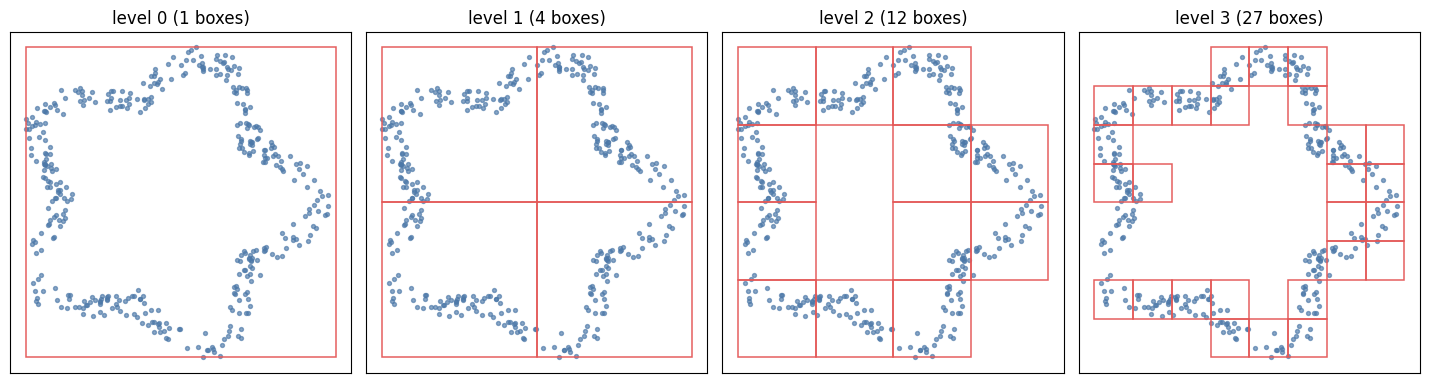

In [4]:
fig, axes = plt.subplots(1, tree.nlevels, figsize=(3.6 * tree.nlevels, 3.8), sharex=True, sharey=True)
if tree.nlevels == 1:
    axes = [axes]

for lev, ax in enumerate(axes):
    ax.scatter(points[:, 0], points[:, 1], s=8, color="#4c78a8", alpha=0.65)
    draw_boxes(ax, tree, tree.get_boxes_level(lev), color="#e45756", lw=1.1, alpha=0.95)
    ax.set_title(f"level {lev} ({len(tree.get_boxes_level(lev))} boxes)")
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()


## Recursive Skeletonization

For each box $B$, the algorithm constructs a small index set $S_B$ that serves as a compressed representation of the degrees of freedom in that box.

If $B$ is a leaf, the candidate set is simply the set of point indices in that leaf. If $B$ is a non-leaf with children $C_1, \ldots, C_m$, then the candidate set is

$$
I_B = \bigcup_{j=1}^m S_{C_j}.
$$

The parent skeleton $S_B \subset I_B$ is obtained by applying an interpolative decomposition to the proxy interaction matrix for the parent box. Thus the parent no longer sees all descendant points; it only compresses the union of the child skeletons. This nested relation is the central algebraic structure in the method.


## Translation Lists

Once the skeletons have been constructed, the setup stage records the local relations needed by the matrix-vector product. These lists encode same-level near-neighbor interactions together with the coarse/fine relations required by the adaptive tree.


## A Box Together With Its Local Relations

One box is singled out together with its same-level near neighbors and its coarse neighbors. These local geometric relations are precisely the ones that feed the translation stage of the matrix-vector product.


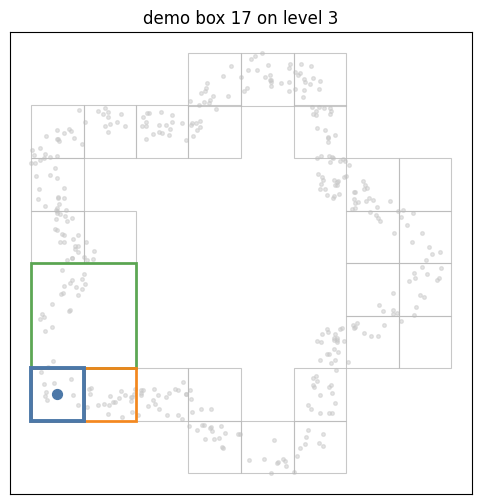

demo box: 17
level: 3
colleagues: [17 18]
coarse neighbors: [6]


In [5]:
demo_box = pick_demo_box(tree, backend)
demo_level = tree.get_box_level(demo_box)
colleagues = np.asarray(tree.get_box_colleague_neigh(demo_box), dtype=int)
coarse = np.asarray(tree.get_box_coarse_neigh(demo_box), dtype=int)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(points[:, 0], points[:, 1], s=7, color="#c7c7c7", alpha=0.45)
draw_boxes(ax, tree, tree.get_boxes_level(demo_level), color="#bbbbbb", lw=0.8, alpha=0.8)
for box in coarse:
    draw_box(ax, tree, int(box), color="#54a24b", lw=2.0, alpha=0.95)
for box in colleagues:
    draw_box(ax, tree, int(box), color="#f58518", lw=2.0, alpha=0.95)
draw_box(ax, tree, demo_box, color="#4c78a8", lw=2.8, alpha=1.0)
center = tree.get_box_center(demo_box)
ax.scatter(center[0], center[1], s=50, color="#4c78a8", zorder=5)
ax.set_title(f"demo box {demo_box} on level {demo_level}")
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

print("demo box:", demo_box)
print("level:", demo_level)
print("colleagues:", colleagues)
print("coarse neighbors:", coarse)

## Stages Of The Matrix-Vector Product

The matrix-vector product is naturally decomposed into three maps,

$$
q \longmapsto q_{\mathrm{skel}} \longmapsto u_{\mathrm{skel}} \longmapsto u,
$$

corresponding to upward compression, levelwise translation, and downward reconstruction. The following computation applies these stages separately and checks that their composition agrees with the full `matvec` call.


In [6]:
random = np.random.RandomState(1)
q = random.randn(tree.N)

y_builtin = fmm.apply(q)

q_vec = backend.get_qorig(q)
q_vec_after, q_skel = backend.compute_qskel(q_vec.copy())
u_vec, u_skel = backend.compute_uskel(q_vec_after, q_skel, verbose=False)
result_vec = backend.resultvec_from_uskel(u_vec.copy(), u_skel.copy())
y_staged = backend.get_result(result_vec)

assert np.allclose(y_staged, y_builtin, atol=1e-12, rtol=1e-12)


## Batched Apply And GPU Acceleration

The batched implementation in
[`skelfmm/batched_fmm.py`](/Users/annayesy/Documents/skel-fmm/skelfmm/batched_fmm.py)
uses the same tree, the same skeleton sets, and the same translation lists. The only change is that many box-box interactions are grouped together and evaluated with the fastest available backend: explicit torch kernels, PyKeOps lazy kernels, or their CUDA variants when the data live on the GPU.


## Dense Reference On A Small Target Subset

To validate the fast apply, we compare it against the direct Laplace evaluation on a small subset of target indices. Mathematically, the notebook checks the relative error

$$
\frac{\|y_{\mathrm{dense}} - y_{\mathrm{fast}}\|}{\|y_{\mathrm{dense}}\|}
$$

on that subset, but we let `SkelFMM` carry out the dense-reference computation internally through `relerr_fmm_apply_check(...)`.


In [7]:
check = np.linspace(0, tree.N - 1, 40, dtype=int)
relerr = fmm.relerr_fmm_apply_check(q, indices=check)
print(f"subset dense-vs-fast relative error: {relerr:.3e}")


subset dense-vs-fast relative error: 5.233e-07


## Paper-To-Code Correspondence

The paper formulates the method in terms of nested skeleton sets and levelwise neighbor translations. In the implementation, the corresponding anchors are the skeleton build, the construction of the translation lists, the upward pass, the translation stage, and the downward pass.
